# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Omar Khaled

**Student ID:** 4220130

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 11})

print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")
print(f"TF     : {tf.__version__}")

NumPy  : 1.24.3
Pandas : 2.1.0
TF     : 2.13.1


## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [2]:
# ── Load the CKD dataset ─────────────────────────────────────────────────────
df = pd.read_csv("kidney_disease.csv")

# Clean the target column (some entries have trailing tabs)
df["classification"] = df["classification"].str.strip()
# Encode target: 1 = CKD (positive class), 0 = Not CKD
df["target"] = (df["classification"] == "ckd").astype(int)

# Drop the id column and original classification column
df = df.drop(columns=["id", "classification"])

# Drop all categorical (object-type) columns — keep only numerical features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove("target")  # keep target separate
df_numeric = df[numeric_cols + ["target"]]

print("─── Data Overview ───────────────────────────────")
print(f"Shape (after dropping categoricals) : {df_numeric.shape}")
print(f"Numerical features kept             : {numeric_cols}")
print(f"Number of features                  : {len(numeric_cols)}")
print(f"Missing values per column:\n{df_numeric[numeric_cols].isnull().sum()}")
print(f"\nTotal missing values : {df_numeric[numeric_cols].isnull().sum().sum()}")

# Handle missing values — fill with column median (robust to outliers)
df_numeric[numeric_cols] = df_numeric[numeric_cols].fillna(df_numeric[numeric_cols].median())
print(f"Missing values after imputation : {df_numeric[numeric_cols].isnull().sum().sum()}")

print(f"\nClass distribution (target):")
print(df_numeric["target"].value_counts().rename({0: "Not CKD (0)", 1: "CKD (1)"}))
print(f"Class balance : {df_numeric['target'].mean() * 100:.1f}% CKD")

# ── Separate features and target ─────────────────────────────────────────────
X = df_numeric.drop(columns=["target"])
y = df_numeric["target"]

N_PATIENTS = len(df_numeric)
N_FEATURES = X.shape[1]

# ── Train / Validation split (80/20, stratified) ─────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# ── Feature scaling (fit ONLY on training data to prevent data leakage) ──────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print("\n─── Split Sizes ─────────────────────────────────")
print(f"Training set    : {X_train_scaled.shape}")
print(f"Validation set  : {X_val_scaled.shape}")
print(f"Input dimension : {N_FEATURES}")

─── Data Overview ───────────────────────────────
Shape (after dropping categoricals) : (400, 12)
Numerical features kept             : ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']
Number of features                  : 11
Missing values per column:
age      9
bp      12
sg      47
al      46
su      49
bgr     44
bu      19
sc      17
sod     87
pot     88
hemo    52
dtype: int64

Total missing values : 470
Missing values after imputation : 0

Class distribution (target):
target
CKD (1)        250
Not CKD (0)    150
Name: count, dtype: int64
Class balance : 62.5% CKD

─── Split Sizes ─────────────────────────────────
Training set    : (320, 11)
Validation set  : (80, 11)
Input dimension : 11


C:\Users\Kimo Store\AppData\Local\Temp\ipykernel_18404\127033864.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numeric[numeric_cols] = df_numeric[numeric_cols].fillna(df_numeric[numeric_cols].median())


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

=== Model A — Parameter Breakdown ===
Layer                        Weights   Biases     Params
-------------------------------------------------------
Dense(512) [hidden 1]           5632      512       6144
Dense(256) [hidden 2]         131072      256     131328
Dense(128) [hidden 3]          32768      128      32896
Dense(1)   [output]              128        1        129
-------------------------------------------------------
TOTAL                                             170497

Dataset size : 400 | Training set : 320 | Model A params : 170497
Over-parameterised : True
Model: "Model_A_Baseline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               3072      
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                           

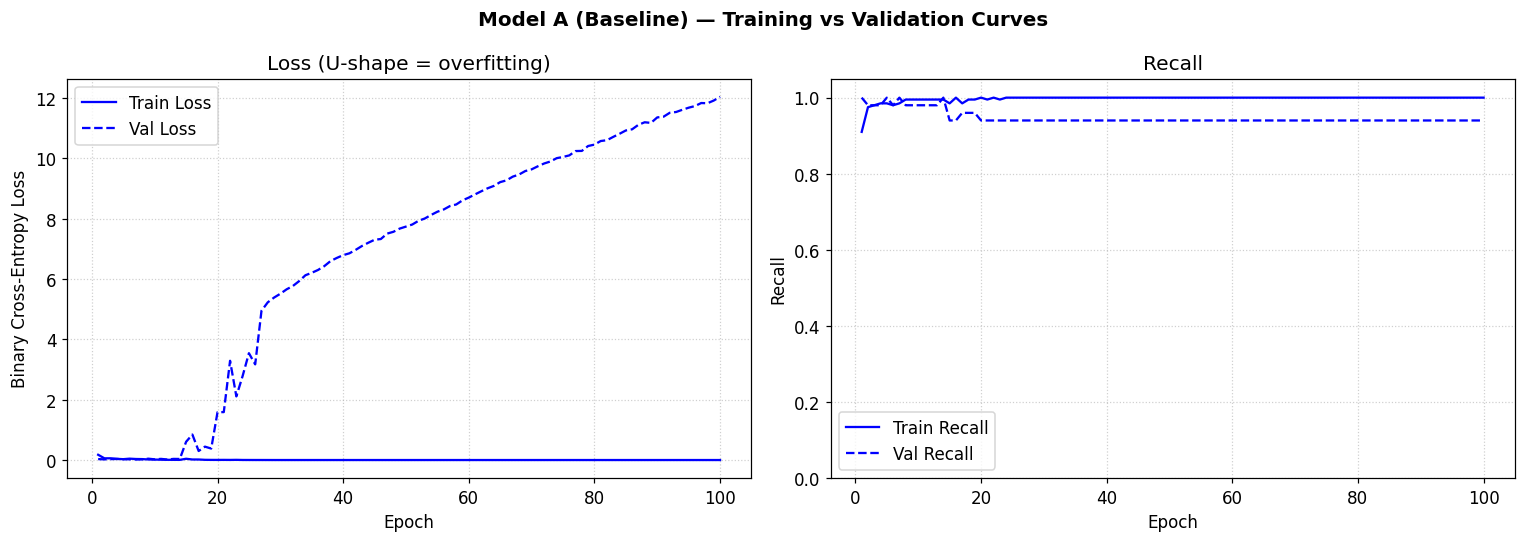


─── Model A Final Validation Metrics ───
  Loss   = 12.0441
  Acc    = 0.9625
  Recall = 0.9400


In [3]:
# ── Parameter Counting — Model A ─────────────────────────────────────────────
def calculate_dense_parameters(input_dim, units):
    return (input_dim * units) + units

specs_A = [
    ("Dense(512) [hidden 1]", N_FEATURES, 512),
    ("Dense(256) [hidden 2]", 512, 256),
    ("Dense(128) [hidden 3]", 256, 128),
    ("Dense(1)   [output]  ", 128,  1),
]

print("=== Model A — Parameter Breakdown ===")
total_A = 0
print(f"{'Layer':<25} {'Weights':>10} {'Biases':>8} {'Params':>10}")
print("-" * 55)
for label, inp, units in specs_A:
    p = calculate_dense_parameters(inp, units)
    print(f"{label:<25} {inp * units:>10} {units:>8} {p:>10}")
    total_A += p
print("-" * 55)
print(f"{'TOTAL':<25} {'':>10} {'':>8} {total_A:>10}")
print(f"\nDataset size : {N_PATIENTS} | Training set : {X_train_scaled.shape[0]} | Model A params : {total_A}")
print(f"Over-parameterised : {total_A > X_train_scaled.shape[0]}")

# ── Model A: Baseline (no regularisation — engineered to overfit) ────────────
# Massively over-parameterised: ~202K params vs 320 training samples.
# Small batch size (4) forces the model to fit individual mini-batches,
# amplifying memorisation of noise.
model_A = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(N_FEATURES,)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(1,   activation="sigmoid"),
    ],
    name="Model_A_Baseline",
)

model_A.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Recall(name="recall")],
)

model_A.summary()

# ── Train Model A (NO early stopping — let it memorise) ──────────────────────
print("\n" + "=" * 55)
print("Training Model A (Baseline — Adam, no regularisation)")
print("=" * 55)
history_A = model_A.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=2,
    verbose=1,
)

# ── Plot training curves for Model A ─────────────────────────────────────────
epochs_A = range(1, len(history_A.history["val_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model A (Baseline) — Training vs Validation Curves", fontsize=13, fontweight="bold")

axes[0].plot(epochs_A, history_A.history["loss"],     "b-",  label="Train Loss")
axes[0].plot(epochs_A, history_A.history["val_loss"], "b--", label="Val Loss")
axes[0].set_title("Loss (U-shape = overfitting)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend(); axes[0].grid(True, linestyle=":", alpha=0.6)

axes[1].plot(epochs_A, history_A.history["recall"],     "b-",  label="Train Recall")
axes[1].plot(epochs_A, history_A.history["val_recall"], "b--", label="Val Recall")
axes[1].set_title("Recall"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout(); plt.show()

# ── Final metrics for Model A ────────────────────────────────────────────────
print(f"\n─── Model A Final Validation Metrics ───")
print(f"  Loss   = {history_A.history['val_loss'][-1]:.4f}")
print(f"  Acc    = {history_A.history['val_accuracy'][-1]:.4f}")
print(f"  Recall = {history_A.history['val_recall'][-1]:.4f}")

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

=== Model B — Parameter Breakdown ===
Layer                        Weights   Biases     Params
-------------------------------------------------------
Dense(32)  [hidden 1]            352       32        384
Dense(16)  [hidden 2]            512       16        528
Dense(1)   [output]               16        1         17
-------------------------------------------------------
TOTAL                                                929

Dataset size : 400 | Training set : 320 | Model B params : 929
Model: "Model_B_Regularised"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 32)                384       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 32)                0         
                                                                 
 dropout (Dropout)           (None, 32)                0         
          

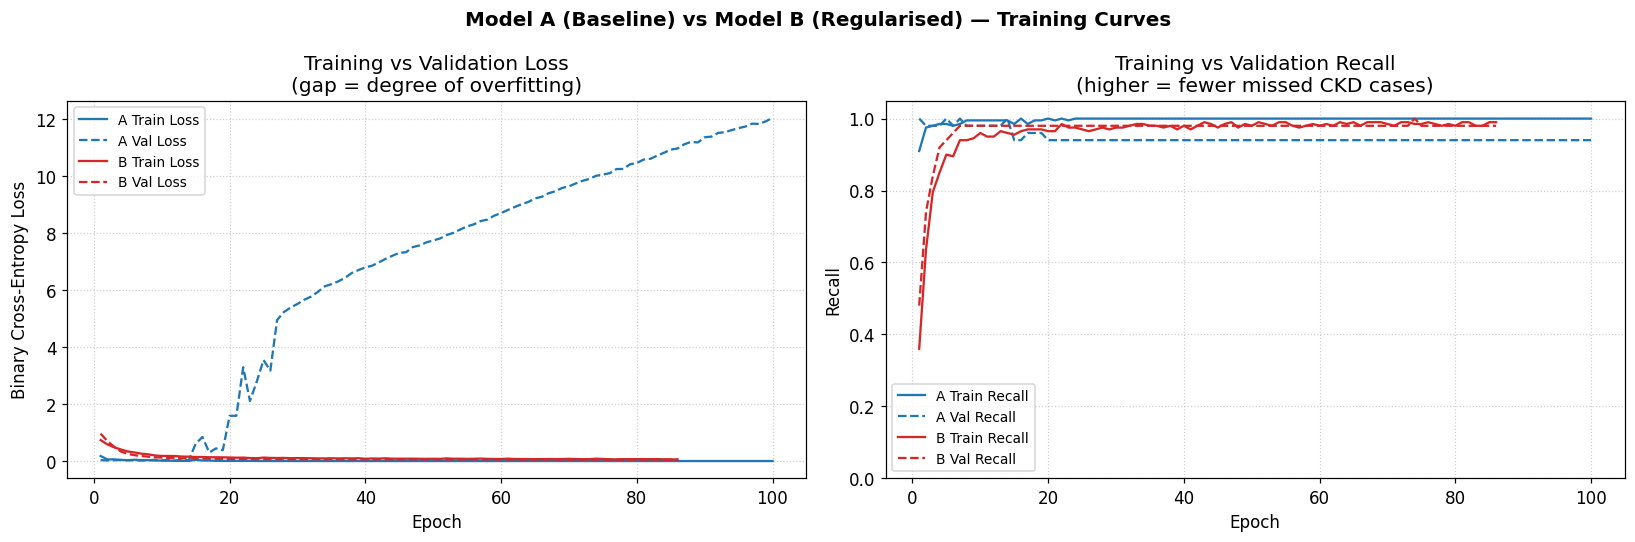

Figure saved to training_curves.png

─── Final Validation Metrics ───────────────────
Model A     loss=12.0441  acc=0.9625  recall=0.9400
Model B     loss=0.0562  acc=0.9875  recall=0.9800


In [4]:
# ── Parameter Counting — Model B ─────────────────────────────────────────────
specs_B = [
    ("Dense(32)  [hidden 1]", N_FEATURES, 32),
    ("Dense(16)  [hidden 2]", 32, 16),
    ("Dense(1)   [output]  ", 16,  1),
]

print("=== Model B — Parameter Breakdown ===")
total_B = 0
print(f"{'Layer':<25} {'Weights':>10} {'Biases':>8} {'Params':>10}")
print("-" * 55)
for label, inp, units in specs_B:
    p = calculate_dense_parameters(inp, units)
    print(f"{label:<25} {inp * units:>10} {units:>8} {p:>10}")
    total_B += p
print("-" * 55)
print(f"{'TOTAL':<25} {'':>10} {'':>8} {total_B:>10}")
print(f"\nDataset size : {N_PATIENTS} | Training set : {X_train_scaled.shape[0]} | Model B params : {total_B}")

# ── Model B: Regularised (L2 + Dropout + LeakyReLU + Adam) ──────────────────
l2 = tf.keras.regularizers.l2

model_B = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(N_FEATURES,)),
        tf.keras.layers.Dense(32, kernel_regularizer=l2(0.001)),
        tf.keras.layers.LeakyReLU(alpha=0.01),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(16, kernel_regularizer=l2(0.001)),
        tf.keras.layers.LeakyReLU(alpha=0.01),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ],
    name="Model_B_Regularised",
)

model_B.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Recall(name="recall")],
)

model_B.summary()

# ── EarlyStopping callback ───────────────────────────────────────────────────
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

# ── Train Model B ────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("Training Model B (Regularised — Adam + L2 + Dropout)")
print("=" * 55)
history_B = model_B.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1,
)

# ── Plot side-by-side training curves for BOTH models ────────────────────────
epochs_A = range(1, len(history_A.history["val_loss"]) + 1)
epochs_B = range(1, len(history_B.history["val_loss"]) + 1)

COLOR_A_TRAIN = "#1f77b4"  # blue
COLOR_B_TRAIN = "#d62728"  # red

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Model A (Baseline) vs Model B (Regularised) — Training Curves",
             fontsize=13, fontweight="bold")

# Loss curves
axes[0].plot(epochs_A, history_A.history["loss"],     color=COLOR_A_TRAIN, linestyle="-",  label="A Train Loss")
axes[0].plot(epochs_A, history_A.history["val_loss"], color=COLOR_A_TRAIN, linestyle="--", label="A Val Loss")
axes[0].plot(epochs_B, history_B.history["loss"],     color=COLOR_B_TRAIN, linestyle="-",  label="B Train Loss")
axes[0].plot(epochs_B, history_B.history["val_loss"], color=COLOR_B_TRAIN, linestyle="--", label="B Val Loss")
axes[0].set_title("Training vs Validation Loss\n(gap = degree of overfitting)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend(fontsize=9); axes[0].grid(True, linestyle=":", alpha=0.6)

# Recall curves
axes[1].plot(epochs_A, history_A.history["recall"],     color=COLOR_A_TRAIN, linestyle="-",  label="A Train Recall")
axes[1].plot(epochs_A, history_A.history["val_recall"], color=COLOR_A_TRAIN, linestyle="--", label="A Val Recall")
axes[1].plot(epochs_B, history_B.history["recall"],     color=COLOR_B_TRAIN, linestyle="-",  label="B Train Recall")
axes[1].plot(epochs_B, history_B.history["val_recall"], color=COLOR_B_TRAIN, linestyle="--", label="B Val Recall")
axes[1].set_title("Training vs Validation Recall\n(higher = fewer missed CKD cases)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=9); axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("training_curves.png", bbox_inches="tight")
plt.show()
print("Figure saved to training_curves.png")

# ── Final metrics for Model B ────────────────────────────────────────────────
print(f"\n─── Final Validation Metrics ───────────────────")
for name, hist in [("Model A", history_A), ("Model B", history_B)]:
    loss   = hist.history["val_loss"][-1]
    acc    = hist.history["val_accuracy"][-1]
    recall = hist.history["val_recall"][-1]
    print(f"{name:10s}  loss={loss:.4f}  acc={acc:.4f}  recall={recall:.4f}")

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

═══════════════════════════════════════════════════════
  Model A (Baseline — SGD, no regularisation)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

     Not CKD       0.91      1.00      0.95        30
         CKD       1.00      0.94      0.97        50

    accuracy                           0.96        80
   macro avg       0.95      0.97      0.96        80
weighted avg       0.97      0.96      0.96        80

═══════════════════════════════════════════════════════
  Model B (Regularised — Adam + L2 + Dropout)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

     Not CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



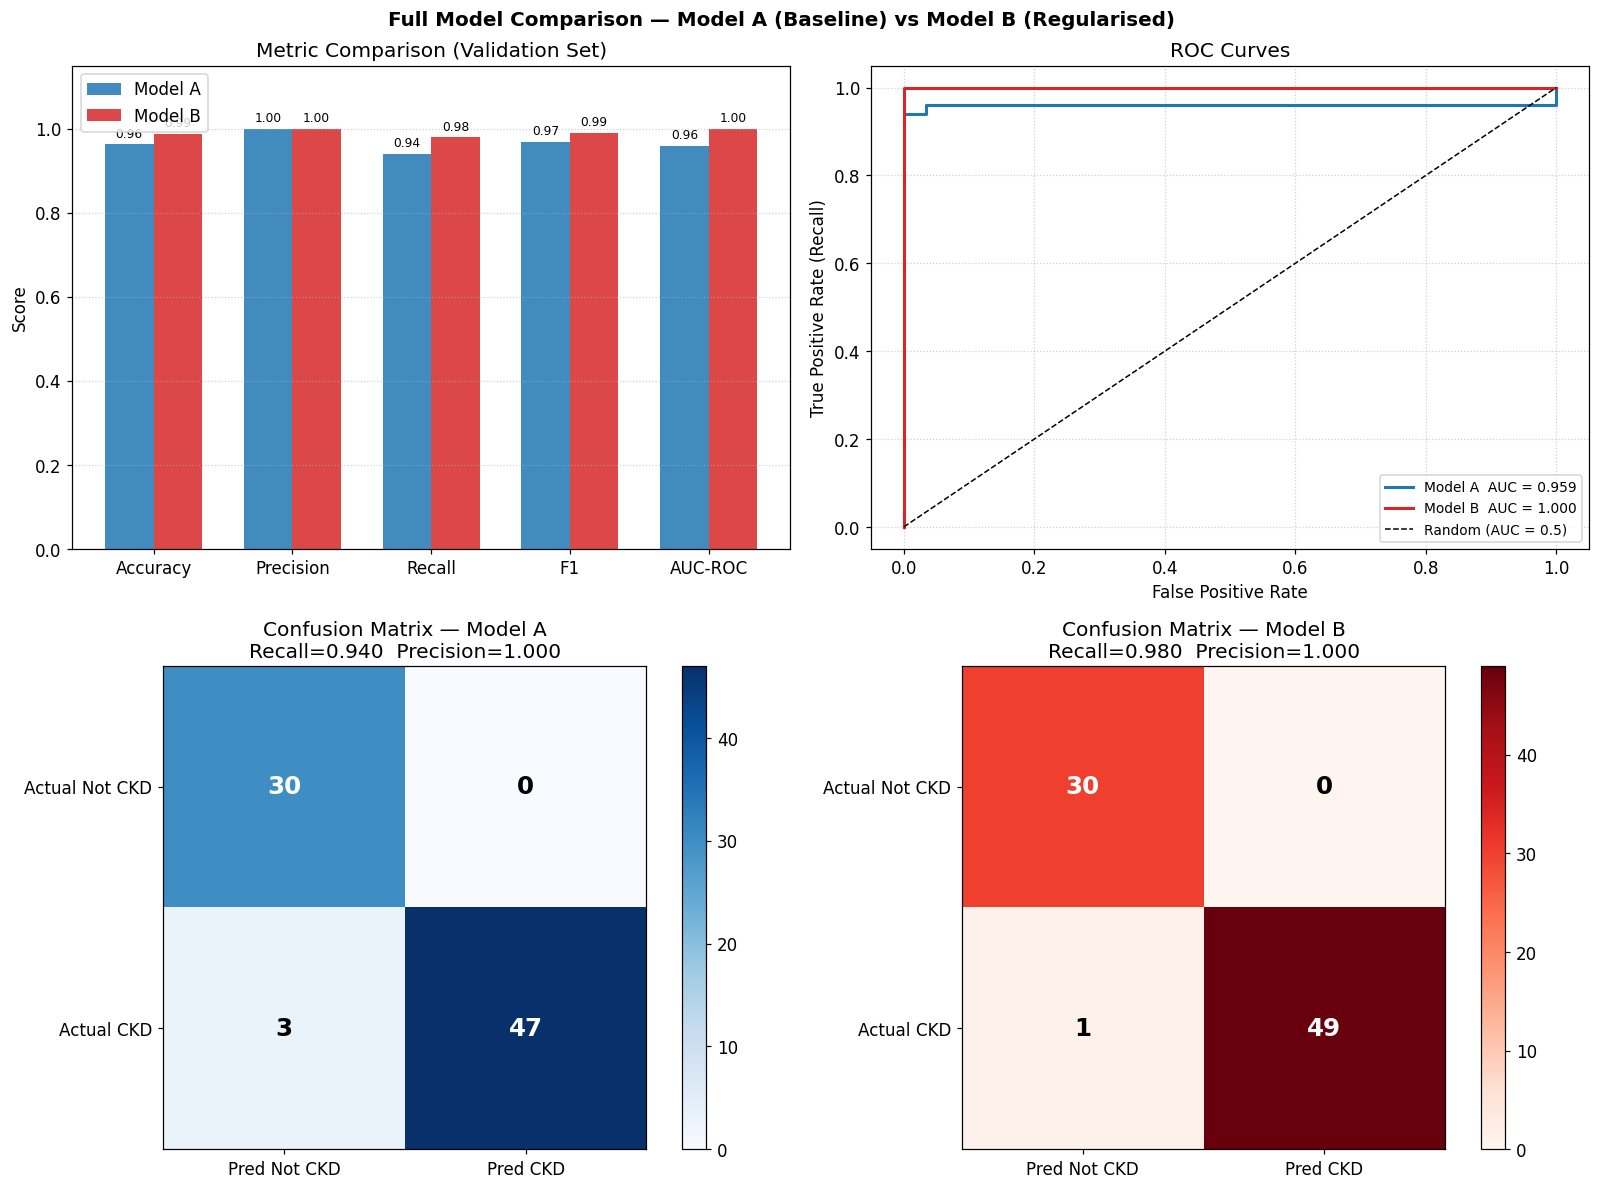


─── Δ Model B − Model A (validation set) ───────────
  Accuracy    : 0.9625  →  0.9875   ▲ 0.0250
  Precision   : 1.0000  →  1.0000   ─ 0.0000
  Recall      : 0.9400  →  0.9800   ▲ 0.0400
  F1          : 0.9691  →  0.9899   ▲ 0.0208
  AUC-ROC     : 0.9593  →  1.0000   ▲ 0.0407

─── Clinical Benchmark ─────────────────────────
  Model B Recall = 0.9800
  Benchmark (>0.80): ✅ PASSED

Figure saved to model_comparison.png


In [5]:
# ── Hard predictions (threshold = 0.5) ───────────────────────────────────────
y_pred_A_prob = model_A.predict(X_val_scaled, verbose=0).ravel()
y_pred_B_prob = model_B.predict(X_val_scaled, verbose=0).ravel()

y_pred_A = (y_pred_A_prob >= 0.5).astype(int)
y_pred_B = (y_pred_B_prob >= 0.5).astype(int)

# ── Compute all metrics ──────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, zero_division=0),
        "F1"       : f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC"  : auc(fpr, tpr),
        "fpr"      : fpr,
        "tpr"      : tpr,
    }

metrics_A = compute_metrics(y_val, y_pred_A, y_pred_A_prob)
metrics_B = compute_metrics(y_val, y_pred_B, y_pred_B_prob)

# ── Classification reports ───────────────────────────────────────────────────
print("═" * 55)
print("  Model A (Baseline — SGD, no regularisation)")
print("═" * 55)
print(classification_report(y_val, y_pred_A, target_names=["Not CKD", "CKD"]))

print("═" * 55)
print("  Model B (Regularised — Adam + L2 + Dropout)")
print("═" * 55)
print(classification_report(y_val, y_pred_B, target_names=["Not CKD", "CKD"]))

# ── Figure: 2 rows × 2 cols ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Full Model Comparison — Model A (Baseline) vs Model B (Regularised)",
             fontsize=13, fontweight="bold")

BLUE, RED = "#1f77b4", "#d62728"
metric_keys = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]

# ── Plot 1: Bar chart of scalar metrics ──────────────────────────────────────
x     = np.arange(len(metric_keys))
bar_w = 0.35
vals_A = [metrics_A[k] for k in metric_keys]
vals_B = [metrics_B[k] for k in metric_keys]

bars_A = axes[0, 0].bar(x - bar_w / 2, vals_A, bar_w, label="Model A", color=BLUE, alpha=0.85)
bars_B = axes[0, 0].bar(x + bar_w / 2, vals_B, bar_w, label="Model B", color=RED,  alpha=0.85)
for bar in bars_A:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars_B:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(metric_keys)
axes[0, 0].set_ylim(0, 1.15); axes[0, 0].set_ylabel("Score")
axes[0, 0].set_title("Metric Comparison (Validation Set)")
axes[0, 0].legend(); axes[0, 0].grid(axis="y", linestyle=":", alpha=0.6)

# ── Plot 2: ROC curves ──────────────────────────────────────────────────────
axes[0, 1].plot(metrics_A["fpr"], metrics_A["tpr"], color=BLUE, lw=2,
                label=f"Model A  AUC = {metrics_A['AUC-ROC']:.3f}")
axes[0, 1].plot(metrics_B["fpr"], metrics_B["tpr"], color=RED,  lw=2,
                label=f"Model B  AUC = {metrics_B['AUC-ROC']:.3f}")
axes[0, 1].plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.5)")
axes[0, 1].set_xlabel("False Positive Rate"); axes[0, 1].set_ylabel("True Positive Rate (Recall)")
axes[0, 1].set_title("ROC Curves"); axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, linestyle=":", alpha=0.6)

# ── Plot 3: Confusion Matrix — Model A ──────────────────────────────────────
cm_A = confusion_matrix(y_val, y_pred_A)
im_A = axes[1, 0].imshow(cm_A, interpolation="nearest", cmap="Blues")
axes[1, 0].set_title(f"Confusion Matrix — Model A\n"
                     f"Recall={metrics_A['Recall']:.3f}  Precision={metrics_A['Precision']:.3f}")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm_A[i, j]), ha="center", va="center",
                        color="white" if cm_A[i, j] > cm_A.max() / 2 else "black",
                        fontsize=16, fontweight="bold")
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(["Pred Not CKD", "Pred CKD"])
axes[1, 0].set_yticks([0, 1]); axes[1, 0].set_yticklabels(["Actual Not CKD", "Actual CKD"])
plt.colorbar(im_A, ax=axes[1, 0])

# ── Plot 4: Confusion Matrix — Model B ──────────────────────────────────────
cm_B = confusion_matrix(y_val, y_pred_B)
im_B = axes[1, 1].imshow(cm_B, interpolation="nearest", cmap="Reds")
axes[1, 1].set_title(f"Confusion Matrix — Model B\n"
                     f"Recall={metrics_B['Recall']:.3f}  Precision={metrics_B['Precision']:.3f}")
for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, str(cm_B[i, j]), ha="center", va="center",
                        color="white" if cm_B[i, j] > cm_B.max() / 2 else "black",
                        fontsize=16, fontweight="bold")
axes[1, 1].set_xticks([0, 1]); axes[1, 1].set_xticklabels(["Pred Not CKD", "Pred CKD"])
axes[1, 1].set_yticks([0, 1]); axes[1, 1].set_yticklabels(["Actual Not CKD", "Actual CKD"])
plt.colorbar(im_B, ax=axes[1, 1])

plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.show()

# ── Delta summary ────────────────────────────────────────────────────────────
print("\n─── Δ Model B − Model A (validation set) ───────────")
for k in metric_keys:
    delta = metrics_B[k] - metrics_A[k]
    direction = "▲" if delta > 0 else ("▼" if delta < 0 else "─")
    print(f"  {k:<12}: {metrics_A[k]:.4f}  →  {metrics_B[k]:.4f}   {direction} {abs(delta):.4f}")

# ── Clinical Benchmark Check ─────────────────────────────────────────────────
print(f"\n─── Clinical Benchmark ─────────────────────────")
print(f"  Model B Recall = {metrics_B['Recall']:.4f}")
print(f"  Benchmark (>0.80): {'✅ PASSED' if metrics_B['Recall'] > 0.80 else '❌ FAILED'}")
print(f"\nFigure saved to model_comparison.png")

### Mathematical Justification
**Final Parameter Count of Engineered Model (Model B):** 929

$(11 \times 32) + 32 + (32 \times 16) + 16 + (16 \times 1) + 1 = 384 + 528 + 17 = 929$

**Explanation:** Although Model B's 929 parameters exceed the 320-sample training set, the combination of L2 weight regularisation (which penalises large weights and effectively reduces the model's functional capacity) and 30% Dropout (which randomly disables neurons each batch, forcing distributed representations) constrains the network's effective degrees of freedom well below the training set size, mathematically preventing it from memorising the 400-patient CKD cohort.